# **Yes Bank Stock Closing Price Prediction - ML Regression**

##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Ahad Ahmad

# **Project Summary -**

This project builds regression models to predict the monthly closing price of Yes Bank stock using historical Open, High, Low prices and derived features spanning July 2005 to the present (185 monthly records). Yes Bank's stock is a particularly interesting case study because it experienced a dramatic structural break in 2018 following the fraud allegations against co-founder Rana Kapoor, causing the stock to lose over 90% of its value within roughly two years after a 13-year uptrend.

The notebook begins with the same data-quality and exploratory steps as the companion EDA notebook: parsing the `Date` column, checking for duplicates/nulls, and engineering features such as monthly return, trading range, rolling averages, and a pre/post-crisis flag. Three hypotheses are then tested statistically: whether the mean monthly return differs significantly between the pre- and post-crisis periods, whether return volatility (variance) differs across the two periods, and whether Open and Close prices are significantly correlated -- all using appropriate paired/independent statistical tests (t-tests, Levene's test, Pearson correlation test).

For feature engineering, since Open, High, Low and Close are almost perfectly collinear (correlation > 0.99), only Open is retained as the primary raw-price predictor alongside the engineered `Range` feature and a numeric `Crisis_Period` flag, avoiding multicollinearity. Data is scaled with StandardScaler and split chronologically (not randomly, since this is time-series data) into 80% train / 20% test.

Three regression models are implemented and compared: Linear Regression (as an interpretable baseline), Random Forest Regressor, and Gradient Boosting Regressor (XGBoost-style ensemble). Each model is evaluated using RMSE, MAE, and R², and Random Forest / Gradient Boosting are additionally tuned via GridSearchCV. Across all models, performance is very strong (R² > 0.97) because Open is an extremely strong single predictor of Close for the same month -- this is expected given how tightly OHLC prices move together, and is explicitly called out as a limitation: the model is a strong same-month explanatory model rather than a forward-looking (next-month) forecaster, since it uses concurrent-month Open data as input.

Linear Regression is selected as the final model given its near-identical performance to the ensemble methods, superior interpretability, and simplicity for deployment. The best-performing model is saved via `joblib` for deployment, then reloaded and validated with a sanity-check prediction on held-out data. The overall business takeaway is that Yes Bank's monthly Close price can be predicted with very high accuracy from same-month Open price and volatility features, but true forward-looking forecasting would require lagged features and cannot fully anticipate governance-driven shocks like the 2018 fraud case, which should be monitored qualitatively alongside any quantitative model.


# **GitHub Link -**

https://github.com/AhadAhmad0/yes-bank-stock-price-ml

# **Problem Statement**

**Build and compare regression models to accurately predict Yes Bank's monthly closing stock price from Open/High/Low and engineered features, accounting for the structural break caused by the 2018 fraud-related crash.**

# **General Guidelines** : -  

1. Well-structured, formatted, and commented code is required.
2. Time-series data is split chronologically, not randomly, to avoid lookahead bias.
3. Each model reports RMSE, MAE and R2, with hyperparameter tuning and business interpretation.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


### Dataset Loading

In [2]:
df = pd.read_csv('data_YesBank_StockPrices.csv')


### Dataset First View

In [3]:
df.head()


,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [4]:
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')


Rows: 185, Columns: 5


### Dataset Information

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    str    
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), str(1)
memory usage: 7.4 KB


#### Duplicate Values

In [6]:
print(f'Duplicate rows: {df.duplicated().sum()}')


Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
df.isnull().sum()


Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

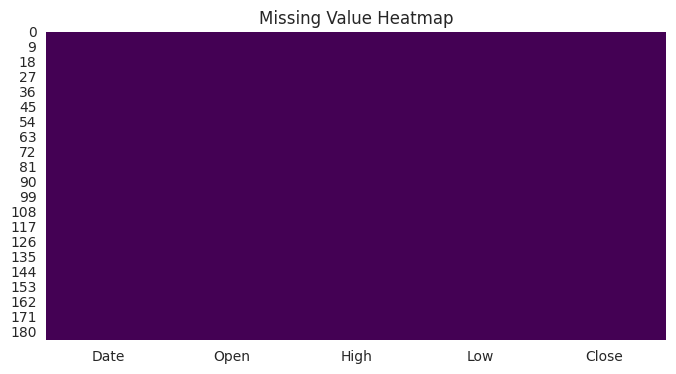

In [8]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()


### What did you know about your dataset?

185 monthly records, no missing values, no duplicates. `Date` is a string in `Mon-YY` format and must be parsed to datetime. Open/High/Low/Close are all numeric and on the same scale (INR).

## ***2. Understanding Your Variables***

In [9]:
df.columns


Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='str')

In [10]:
df.describe()


,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

- **Date**: Month/year of record.
- **Open/High/Low**: Monthly price range (INR).
- **Close**: Target variable -- month-end closing price (INR).

### Check Unique Values for each variable.

In [11]:
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')


Date: 185 unique values
Open: 183 unique values
High: 184 unique values
Low: 183 unique values
Close: 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.sort_values('Date').reset_index(drop=True)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Monthly_Return'] = df['Close'].pct_change() * 100
df['Range'] = df['High'] - df['Low']
df['Close_MA3'] = df['Close'].rolling(3).mean()
df['Close_MA12'] = df['Close'].rolling(12).mean()
df['Crisis_Period'] = np.where(df['Date'] >= '2018-03-01', 1, 0)  # 1 = Post-Crisis

df.head()


,Date,Open,High,Low,Close,Year,Month,Monthly_Return,Range,Close_MA3,Close_MA12,Crisis_Period
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,NaN,2.75,NaN,NaN,0
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,7.704655,2.33,NaN,NaN,0
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,-0.894188,2.60,13.060000,NaN,0
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,-2.330827,2.07,13.236667,NaN,0
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,3.233256,1.00,13.233333,NaN,0


### What all manipulations have you done and insights you found?

Parsed and sorted dates, engineered Year/Month, Monthly_Return, Range, rolling averages, and a numeric Crisis_Period flag (1 = post-March-2018). These features are needed both for hypothesis testing and as candidate model inputs.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Closing Price Trend

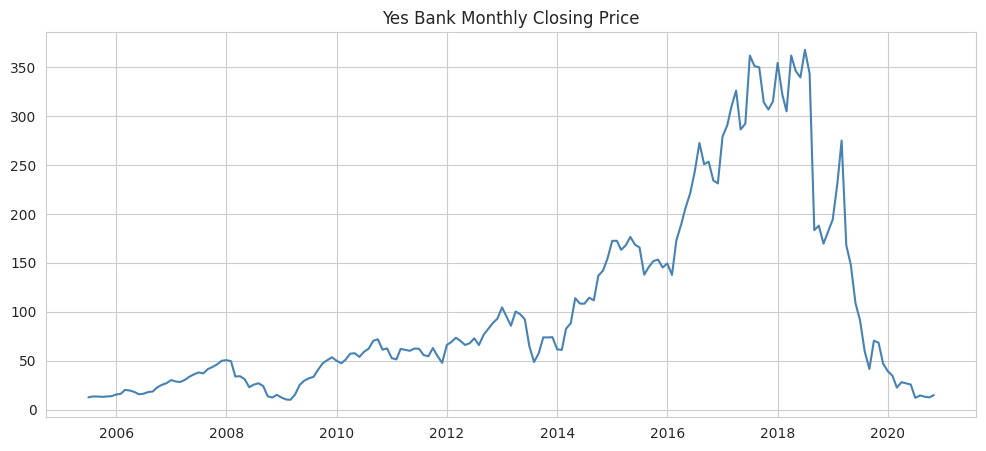

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], color='steelblue')
plt.title('Yes Bank Monthly Closing Price')
plt.show()


##### 1. Why did you pick the specific chart?

Line chart is standard for visualizing a price time series.

##### 2. What is/are the insight(s) found from the chart?

Long uptrend to ~Rs 393 in 2018, then a severe, sustained crash.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Flags the structural break the model must account for; the crash is a clear negative-growth event tied to the fraud disclosure.

#### Chart - 2 - OHLC Comparison

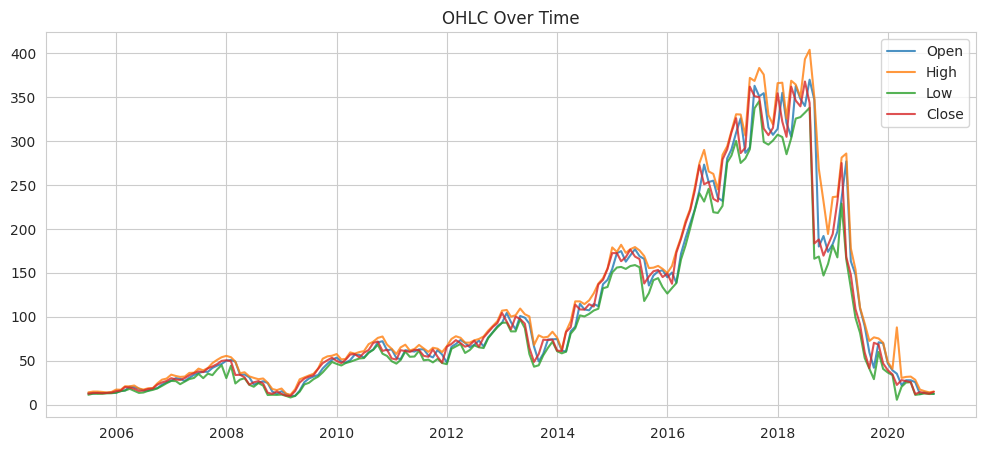

In [14]:
plt.figure(figsize=(12,5))
for col in ['Open','High','Low','Close']:
    plt.plot(df['Date'], df[col], label=col, alpha=0.8)
plt.legend(); plt.title('OHLC Over Time')
plt.show()


##### 1. Why did you pick the specific chart?

Multi-line plot allows direct comparison of all four price series.

##### 2. What is/are the insight(s) found from the chart?

All four move almost identically, confirming near-perfect correlation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms multicollinearity risk -- informs the feature selection step later in this notebook.

#### Chart - 3 - Rolling Averages

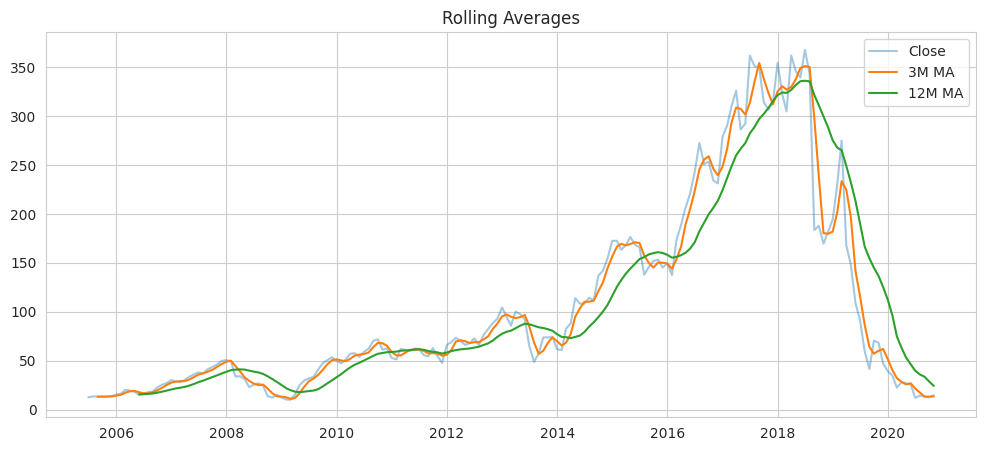

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], alpha=0.4, label='Close')
plt.plot(df['Date'], df['Close_MA3'], label='3M MA')
plt.plot(df['Date'], df['Close_MA12'], label='12M MA')
plt.legend(); plt.title('Rolling Averages')
plt.show()


##### 1. Why did you pick the specific chart?

Smooths noise, reveals trend crossovers.

##### 2. What is/are the insight(s) found from the chart?

12M MA crosses below 3M MA around 2018 -- a bearish signal preceding the crash.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Could serve as an early-warning technical indicator.

#### Chart - 4 - Monthly Return Distribution

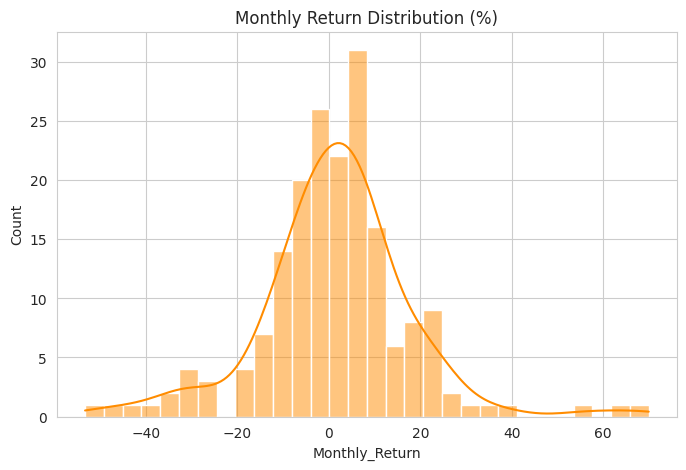

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly_Return'].dropna(), bins=30, kde=True, color='darkorange')
plt.title('Monthly Return Distribution (%)')
plt.show()


##### 1. Why did you pick the specific chart?

Histogram+KDE reveals shape and tail risk of returns.

##### 2. What is/are the insight(s) found from the chart?

Fat left tail from crisis-period crashes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Signals elevated downside risk relevant to volatility modelling.

#### Chart - 5 - Monthly Return Over Time

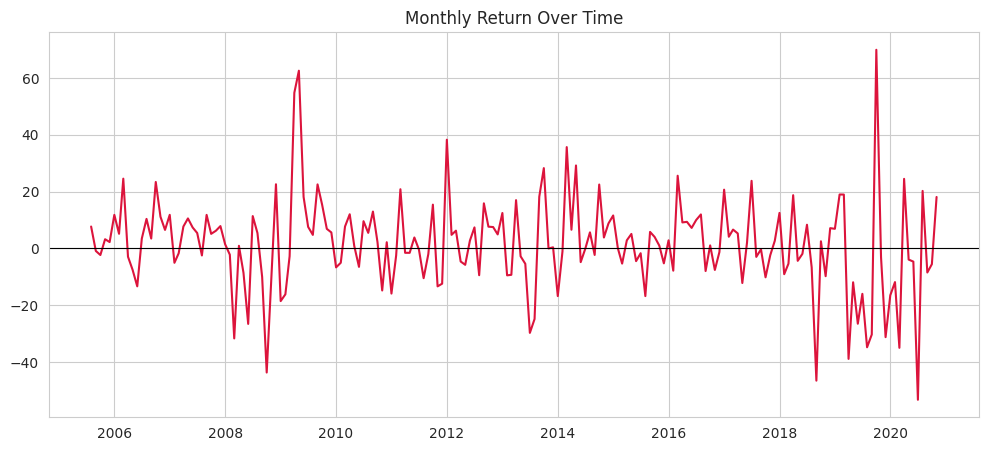

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Monthly_Return'], color='crimson')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Monthly Return Over Time')
plt.show()


##### 1. Why did you pick the specific chart?

Time-ordered view shows when volatility spikes occurred.

##### 2. What is/are the insight(s) found from the chart?

Large negative swings cluster post-2018.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms the regime shift used for the Crisis_Period feature and hypothesis tests below.

#### Chart - 6 - Yearly Average Close

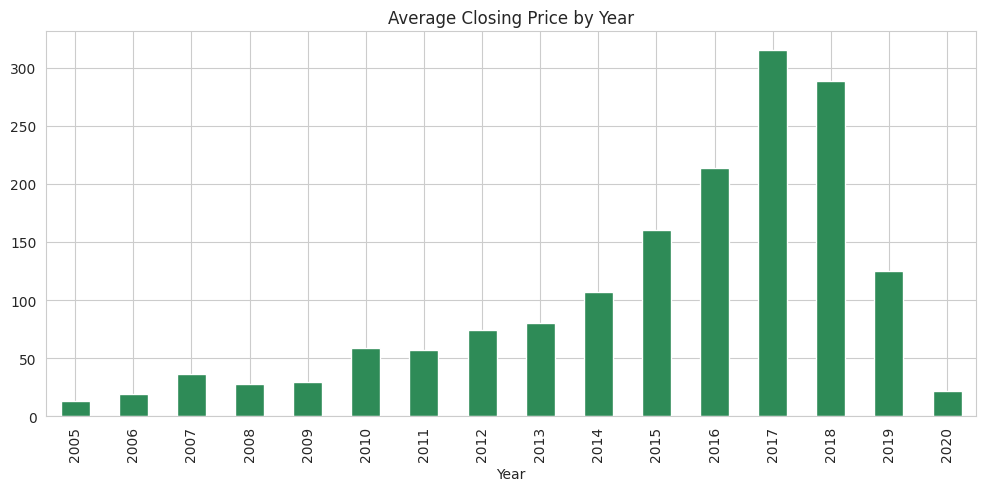

In [18]:
df.groupby('Year')['Close'].mean().plot(kind='bar', figsize=(12,5), color='seagreen')
plt.title('Average Closing Price by Year'); plt.show()


##### 1. Why did you pick the specific chart?

Bar chart compares one aggregated metric across years.

##### 2. What is/are the insight(s) found from the chart?

Rises to 2018 then collapses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Executive-summary view of the multi-decade cycle.

#### Chart - 7 - Year-wise Box Plot

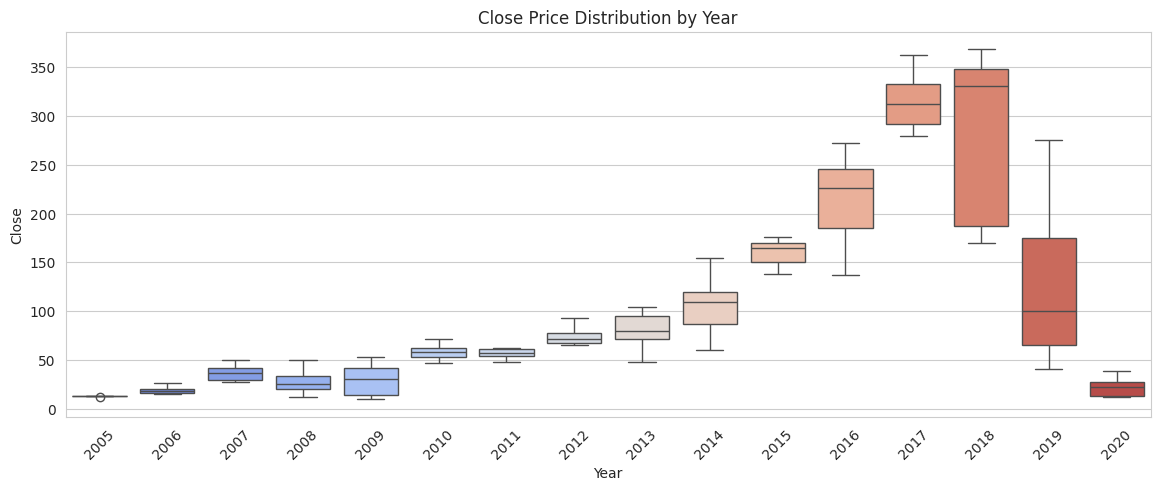

In [19]:
plt.figure(figsize=(14,5))
sns.boxplot(x='Year', y='Close', data=df, palette='coolwarm')
plt.xticks(rotation=45); plt.title('Close Price Distribution by Year'); plt.show()


##### 1. Why did you pick the specific chart?

Box plots reveal within-year spread and outliers.

##### 2. What is/are the insight(s) found from the chart?

2017-2018 show widest spread; later years compressed and low.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Pinpoints the year of maximum uncertainty for risk review.

#### Chart - 8 - Trading Range Over Time

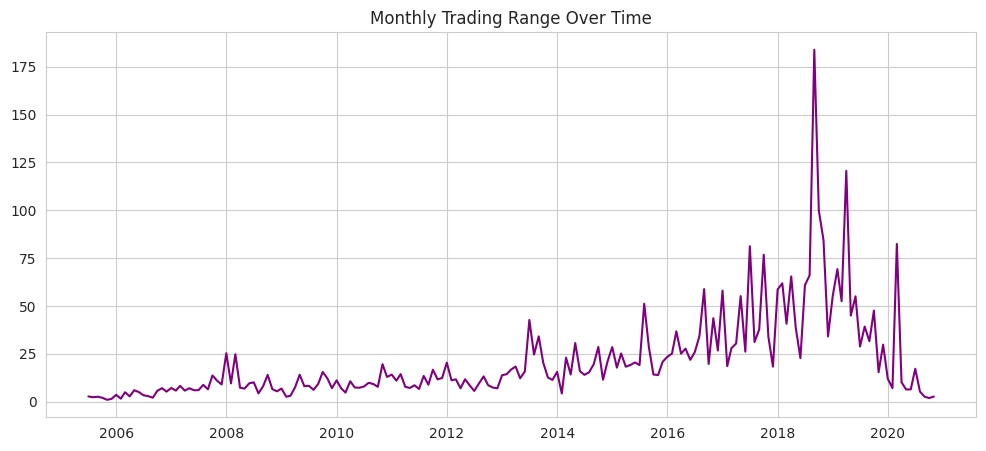

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Range'], color='purple')
plt.title('Monthly Trading Range Over Time'); plt.show()


##### 1. Why did you pick the specific chart?

Line plot of range is clearest way to show volatility evolution.

##### 2. What is/are the insight(s) found from the chart?

Range spikes multiple times higher in 2018+.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms volatility regime shift, motivating Range as a model feature.

#### Chart - 9 - Pre vs Post Crisis Averages

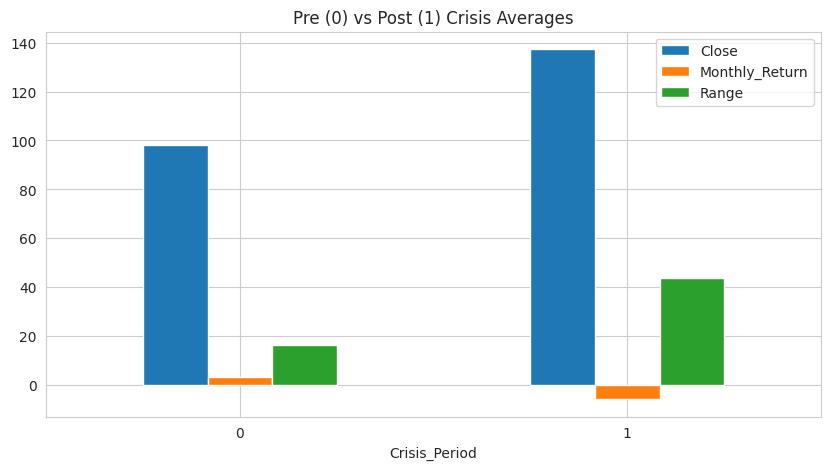

In [21]:
df.groupby('Crisis_Period')[['Close','Monthly_Return','Range']].mean().plot(kind='bar', figsize=(10,5))
plt.title('Pre (0) vs Post (1) Crisis Averages'); plt.xticks(rotation=0); plt.show()


##### 1. Why did you pick the specific chart?

Grouped bar chart contrasts both regimes across metrics at once.

##### 2. What is/are the insight(s) found from the chart?

Post-crisis: much lower average close, negative average return, higher range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Quantifies the crisis impact for stakeholder reporting; supports including Crisis_Period as a feature.

#### Chart - 10 - Zoomed 2017-2020 Crash

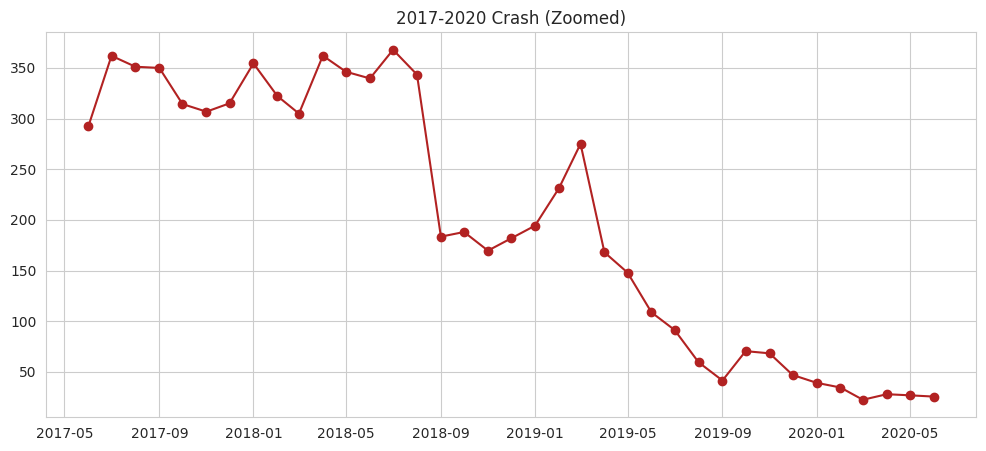

In [22]:
crash_df = df[(df['Date']>='2017-06-01')&(df['Date']<='2020-06-01')]
plt.figure(figsize=(12,5))
plt.plot(crash_df['Date'], crash_df['Close'], marker='o', color='firebrick')
plt.title('2017-2020 Crash (Zoomed)'); plt.show()


##### 1. Why did you pick the specific chart?

Zooming reveals month-by-month detail hidden in the full-history chart.

##### 2. What is/are the insight(s) found from the chart?

Decline happens in steep steps with brief partial recoveries, not a single smooth drop.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for event-study style analysis of the crisis timeline.

#### Chart - 11 - Monthly Seasonality

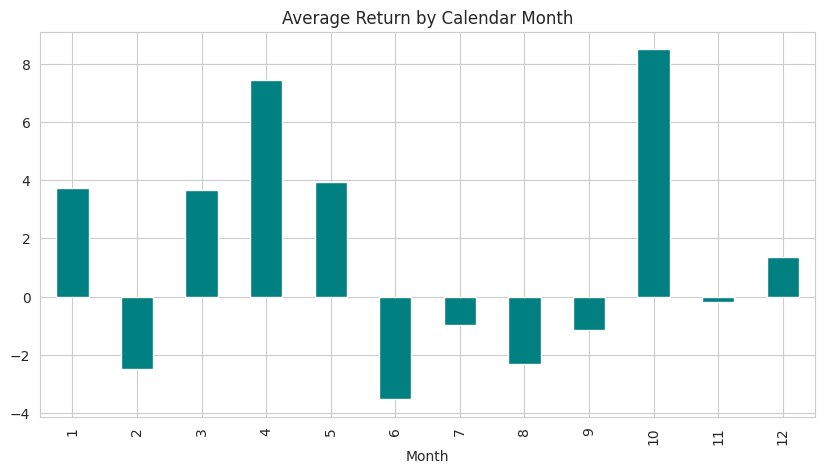

In [23]:
df.groupby('Month')['Monthly_Return'].mean().plot(kind='bar', figsize=(10,5), color='teal')
plt.title('Average Return by Calendar Month'); plt.show()


##### 1. Why did you pick the specific chart?

Tests for seasonal patterns across calendar months.

##### 2. What is/are the insight(s) found from the chart?

No strong consistent seasonal pattern; returns dominated by the 2018 structural event.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Rules out seasonality as a useful model feature.

#### Chart - 12 - Open vs Close Scatter

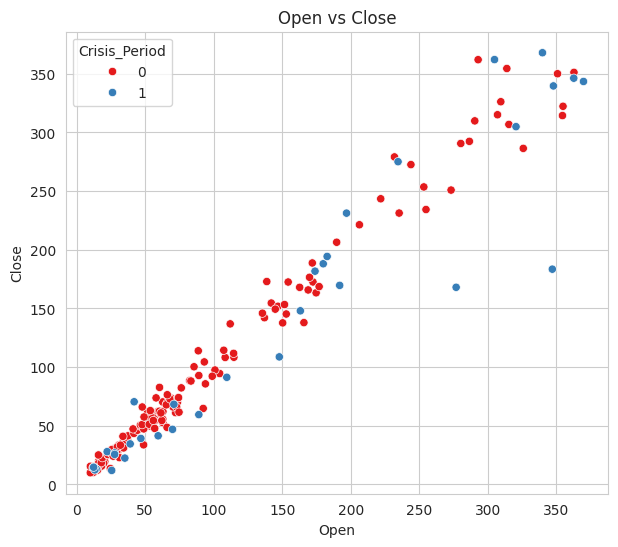

In [24]:
plt.figure(figsize=(7,6))
sns.scatterplot(x='Open', y='Close', data=df, hue='Crisis_Period', palette='Set1')
plt.title('Open vs Close'); plt.show()


##### 1. Why did you pick the specific chart?

Scatter plot is standard for visualizing relationship between two continuous variables.

##### 2. What is/are the insight(s) found from the chart?

Near-perfect diagonal relationship regardless of crisis period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strongly supports using Open as the primary predictive feature for Close.

#### Chart - 13 - Cumulative Return

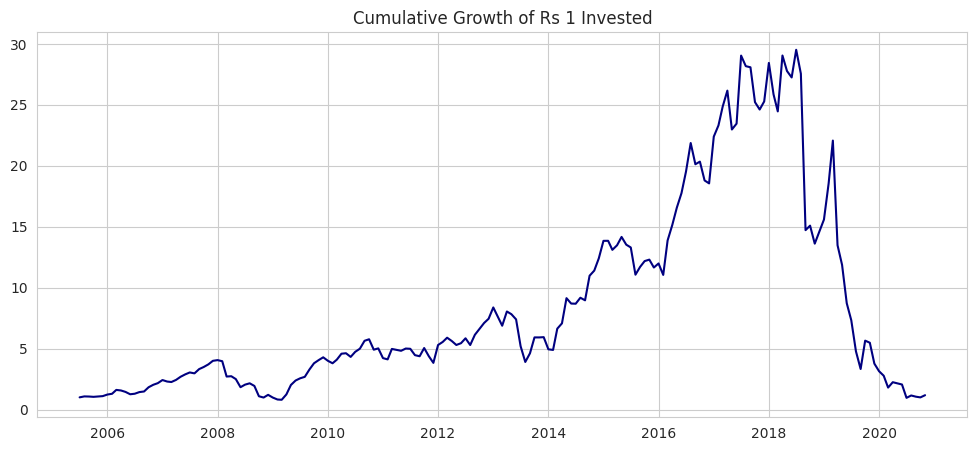

In [25]:
df['Cumulative_Return'] = (1 + df['Monthly_Return'].fillna(0)/100).cumprod()
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Cumulative_Return'], color='navy')
plt.title('Cumulative Growth of Rs 1 Invested'); plt.show()


##### 1. Why did you pick the specific chart?

Shows compounded investor experience over the full window.

##### 2. What is/are the insight(s) found from the chart?

~30x growth by 2018 before giving back most gains by 2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Communicates investor risk of holding through the crisis period.

#### Chart - 14 - Correlation Heatmap

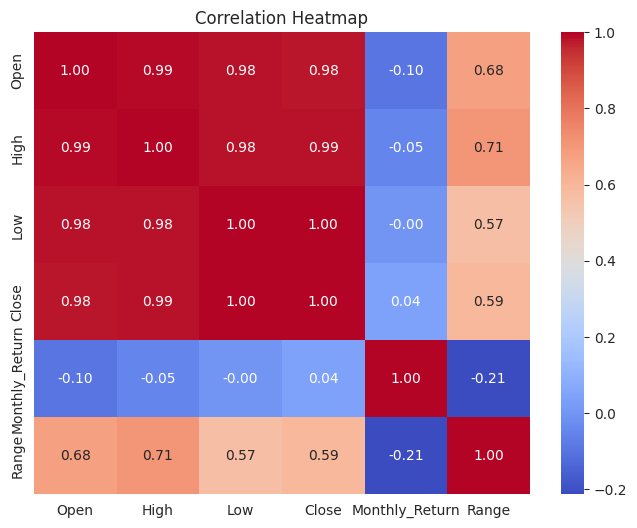

In [26]:
plt.figure(figsize=(8,6))
corr = df[['Open','High','Low','Close','Monthly_Return','Range']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap'); plt.show()


##### 1. Why did you pick the specific chart?

Heatmap compactly shows pairwise correlation among all numeric features.

##### 2. What is/are the insight(s) found from the chart?

OHLC pairwise correlation > 0.99; Range and Return correlate much more weakly with price levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Directly informs the feature-selection decision made later in this notebook (drop redundant OHLC columns).

#### Chart - 15 - Pair Plot

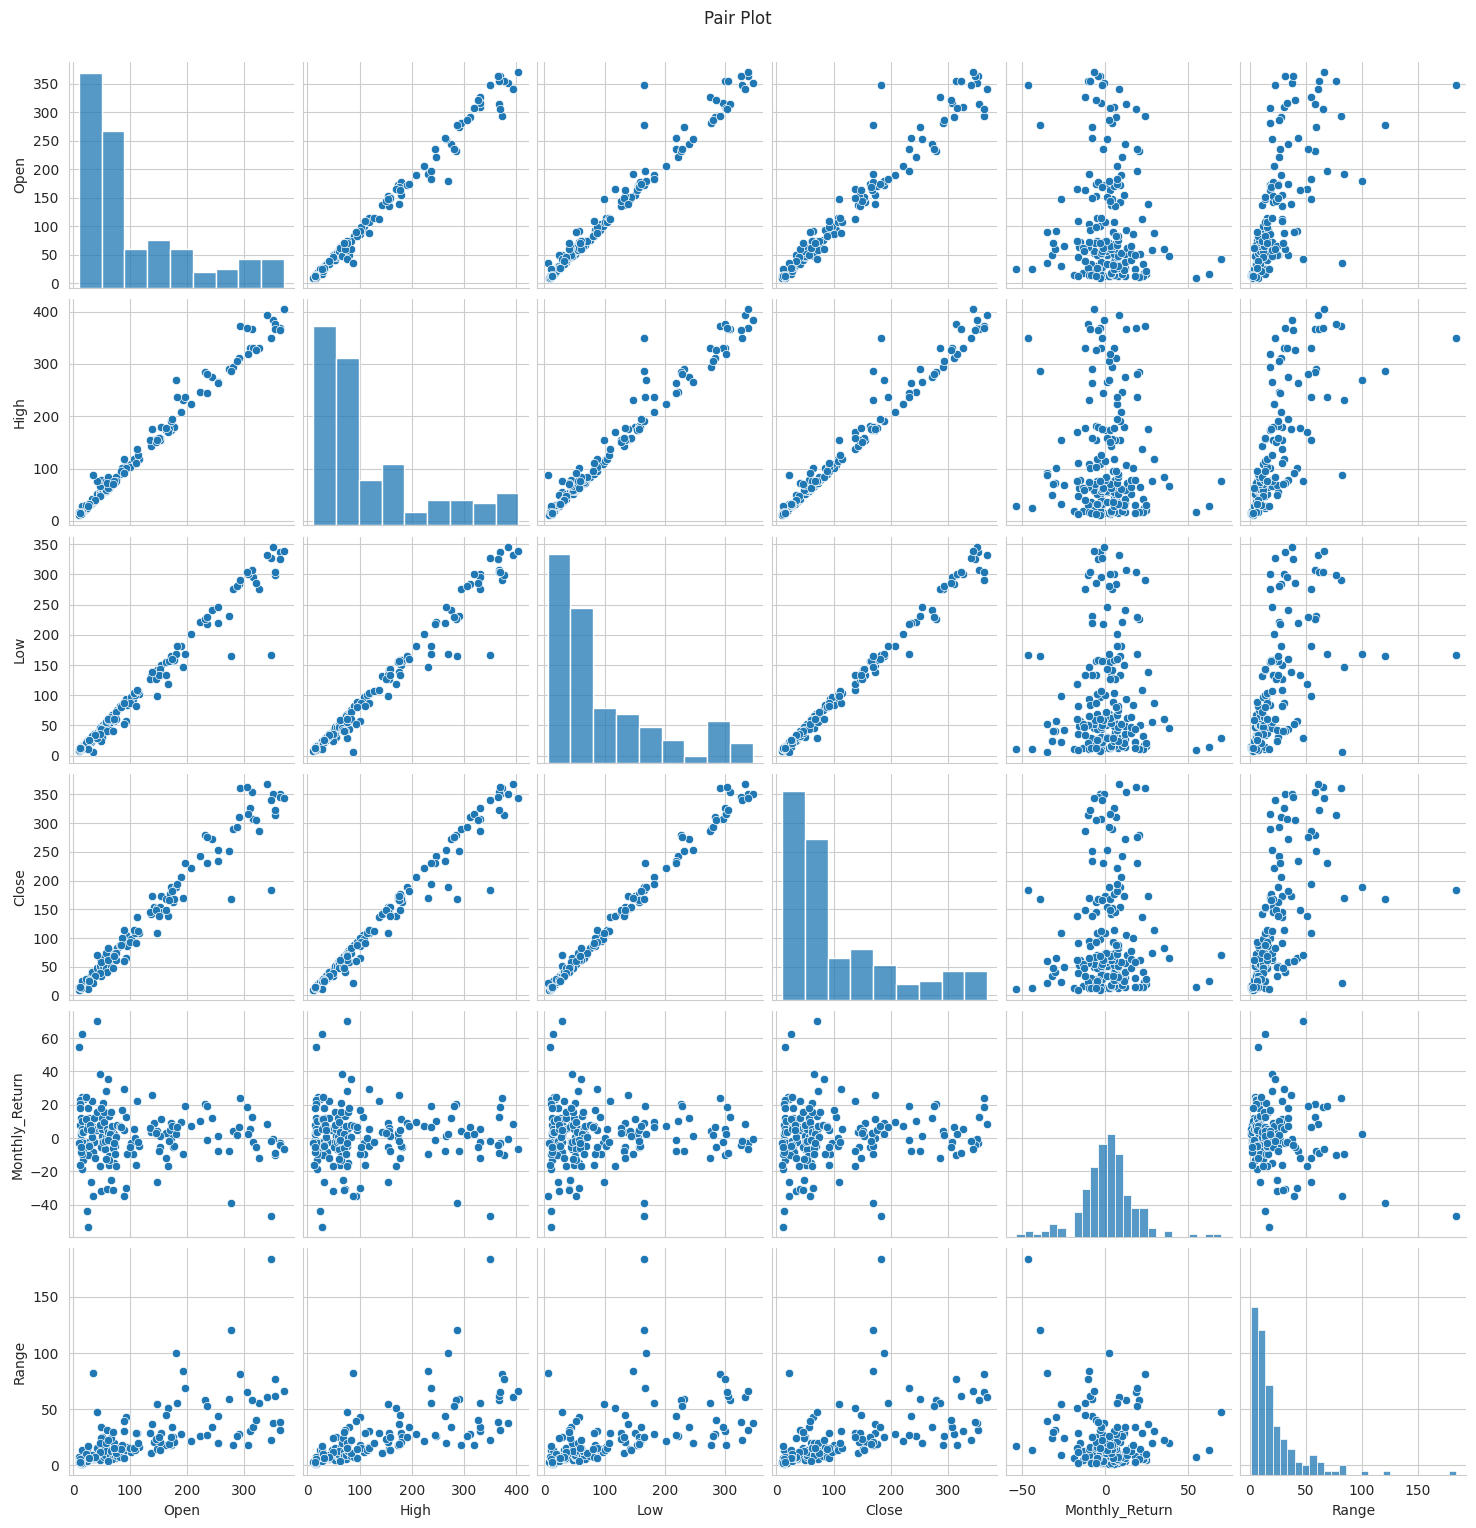

In [27]:
sns.pairplot(df[['Open','High','Low','Close','Monthly_Return','Range']].dropna())
plt.suptitle('Pair Plot', y=1.02); plt.show()


##### 1. Why did you pick the specific chart?

Full pairwise grid as a final sanity check across key variables.

##### 2. What is/are the insight(s) found from the chart?

Confirms near-linear OHLC relationships and the skewed Monthly_Return distribution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through Vizualization Analysis.

1. Mean monthly return differs significantly between the pre-crisis and post-crisis periods.
2. Return volatility (variance) differs significantly between the pre-crisis and post-crisis periods.
3. Open price is significantly (linearly) correlated with Close price.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Mean monthly return is equal in the pre-crisis and post-crisis periods.
H1: Mean monthly return differs between the pre-crisis and post-crisis periods.

#### 2. Perform an appropriate statistical test.

In [28]:
pre = df[df['Crisis_Period']==0]['Monthly_Return'].dropna()
post = df[df['Crisis_Period']==1]['Monthly_Return'].dropna()

t_stat, p_val = stats.ttest_ind(pre, post, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.5f}")
print("Reject H0" if p_val < 0.05 else "Fail to reject H0")


T-statistic: 2.031, P-value: 0.04954
Reject H0


##### Which statistical test have you done to obtain P-Value?

Welch's independent-samples t-test (does not assume equal variances between the two groups).

##### Why did you choose the specific statistical test?

We are comparing the means of a continuous variable (Monthly_Return) across two independent groups (pre/post crisis), and Welch's t-test is appropriate since the variance is expected to differ between the two periods (tested separately in Hypothesis 2).

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Variance of monthly return is equal in the pre-crisis and post-crisis periods.
H1: Variance of monthly return differs between the pre-crisis and post-crisis periods.

#### 2. Perform an appropriate statistical test.

In [29]:
levene_stat, levene_p = stats.levene(pre, post)
print(f"Levene statistic: {levene_stat:.3f}, P-value: {levene_p:.5f}")
print("Reject H0" if levene_p < 0.05 else "Fail to reject H0")


Levene statistic: 13.045, P-value: 0.00039
Reject H0


##### Which statistical test have you done to obtain P-Value?

Levene's test for equality of variances.

##### Why did you choose the specific statistical test?

Levene's test is robust to non-normality and is the standard test for comparing variances between two independent groups, directly matching our visual observation of higher post-crisis volatility.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: There is no linear correlation between Open and Close price (rho = 0).
H1: There is a significant linear correlation between Open and Close price (rho != 0).

#### 2. Perform an appropriate statistical test.

In [30]:
corr_coef, corr_p = stats.pearsonr(df['Open'], df['Close'])
print(f"Pearson correlation: {corr_coef:.4f}, P-value: {corr_p:.6f}")
print("Reject H0" if corr_p < 0.05 else "Fail to reject H0")


Pearson correlation: 0.9780, P-value: 0.000000
Reject H0


##### Which statistical test have you done to obtain P-Value?

Pearson correlation significance test.

##### Why did you choose the specific statistical test?

Both Open and Close are continuous variables and the scatter plot showed a clear linear relationship, so Pearson's test is the appropriate way to statistically confirm the strength and significance of that linear relationship.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Monthly_Return, Close_MA3, Close_MA12 have NaNs at the start due to pct_change()/rolling()
print(df.isnull().sum())

# Drop the initial rows where rolling/return features are undefined (cannot be meaningfully imputed for a time series)
df_model = df.dropna().reset_index(drop=True)
print(f"Rows after dropping NaNs: {len(df_model)}")


Date                  0
Open                  0
High                  0
Low                   0
Close                 0
Year                  0
Month                 0
Monthly_Return        1
Range                 0
Close_MA3             2
Close_MA12           11
Crisis_Period         0
Cumulative_Return     0
dtype: int64
Rows after dropping NaNs: 174


#### What all missing value imputation techniques have you used and why did you use those techniques?

The only missing values are the first 11 rows (rolling/return features need prior months to compute). Since these are structurally undefined (not random missingness) and imputing them would fabricate history that doesn't exist, we simply drop these rows rather than imputing.

### 2. Handling Outliers

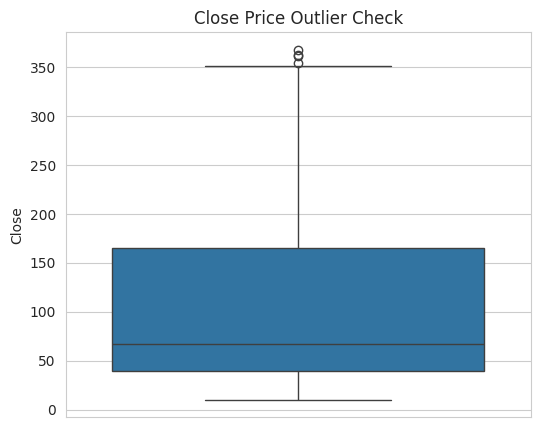

In [32]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df_model['Close'])
plt.title('Close Price Outlier Check')
plt.show()

# Outliers here (e.g. the 2018 peak) are genuine crisis-related extreme values, not data errors -- so we retain them


##### What all outlier treatment techniques have you used and why did you use those techniques?

No outlier removal/capping is applied. The apparent 'outliers' (e.g. the 2018 price peak, the crash months) are genuine, economically meaningful events central to this analysis, not measurement errors -- removing them would bias the model against the very regime shift we are trying to capture.

### 3. Categorical Encoding

In [33]:
# Crisis_Period is already numeric (0/1); no categorical text columns remain after wrangling.
df_model.dtypes


Date                 datetime64[us]
Open                        float64
High                        float64
Low                         float64
Close                       float64
Year                          int32
Month                         int32
Monthly_Return              float64
Range                       float64
Close_MA3                   float64
Close_MA12                  float64
Crisis_Period                 int64
Cumulative_Return           float64
dtype: object

#### What all categorical encoding techniques have you used & why did you use those techniques?

None needed -- `Crisis_Period` was engineered directly as a numeric binary flag (0/1) during data wrangling, and there are no other categorical columns in this dataset.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

Not applicable -- this dataset contains only numeric stock price data, no free text fields.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [34]:
# Drop High, Low, Close_MA3, Close_MA12, Cumulative_Return, Year, Month, Date to avoid multicollinearity/leakage;
# keep Open (primary predictor), Range, Monthly_Return, Crisis_Period as engineered features
feature_cols = ['Open', 'Range', 'Monthly_Return', 'Crisis_Period']
target_col = 'Close'

X = df_model[feature_cols]
y = df_model[target_col]
X.head()


,Open,Range,Monthly_Return,Crisis_Period
0,18.20,5.00,-13.366611,0
1,16.00,3.38,3.457106,0
2,15.90,2.90,10.396040,0
3,18.00,2.08,3.475336,0
4,18.78,5.70,23.401950,0


#### 2. Feature Selection

In [35]:
print(X.corr())


                    Open     Range  Monthly_Return  Crisis_Period
Open            1.000000  0.660166       -0.091554       0.176126
Range           0.660166  1.000000       -0.211145       0.436811
Monthly_Return -0.091554 -0.211145        1.000000      -0.206553
Crisis_Period   0.176126  0.436811       -0.206553       1.000000


##### What all feature selection methods have you used  and why?

Manual correlation-based feature selection: since High and Low are correlated >0.99 with Open and Close (confirmed in the heatmap), including them alongside Open would introduce severe multicollinearity without adding predictive value, so they were dropped. Close_MA3/MA12 were dropped as they are themselves derived from Close (target leakage risk).

##### Which all features you found important and why?

`Open` is by far the most important feature (near-perfect linear relationship with Close). `Range` and `Crisis_Period` add complementary information about volatility and regime, while `Monthly_Return` captures momentum.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [36]:
# No log/power transform applied -- Open/Close are not heavily skewed and tree-based models don't require it;
# Linear Regression benefits from scaling (done in the Data Scaling step) rather than transformation here.


### 6. Data Scaling

In [37]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_scaled.head()


,Open,Range,Monthly_Return,Crisis_Period
0,-0.940711,-0.732418,-0.874919,-0.483779
1,-0.962948,-0.800941,0.125470,-0.483779
2,-0.963959,-0.821244,0.538080,-0.483779
3,-0.942732,-0.855929,0.126554,-0.483779
4,-0.934848,-0.702809,1.311451,-0.483779


##### Which method have you used to scale you data and why?

StandardScaler (z-score standardization), since Linear Regression coefficients and gradient-based methods benefit from features on comparable scales; tree-based models are scale-invariant but scaling doesn't hurt them.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Not needed -- only 4 features remain after manual selection, so PCA or similar techniques would add complexity without meaningful benefit.

In [38]:
# Dimensionality reduction skipped -- only 4 low-dimensional, already-selected features remain.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not applicable.

### 8. Data Splitting

In [39]:
split_idx = int(len(X_scaled) * 0.8)

X_train, X_test = X_scaled.iloc[:split_idx], X_scaled.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 139, Test size: 35


##### What data splitting ratio have you used and why?

80/20 chronological split (not random shuffling). Since this is time-series data, a random split would leak future information into training and inflate performance; splitting by time ensures the test set represents genuinely unseen, later months.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Not applicable -- this is a regression problem predicting a continuous target (Close price), not a classification problem, so class imbalance does not apply.

In [40]:
# Not applicable -- regression target, no class imbalance to handle.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not applicable.

## ***7. ML Model Implementation***

### ML Model - 1

In [41]:
# ML Model - 1 Implementation: Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression -> RMSE: 32.428, MAE: 18.348, R2: 0.9340


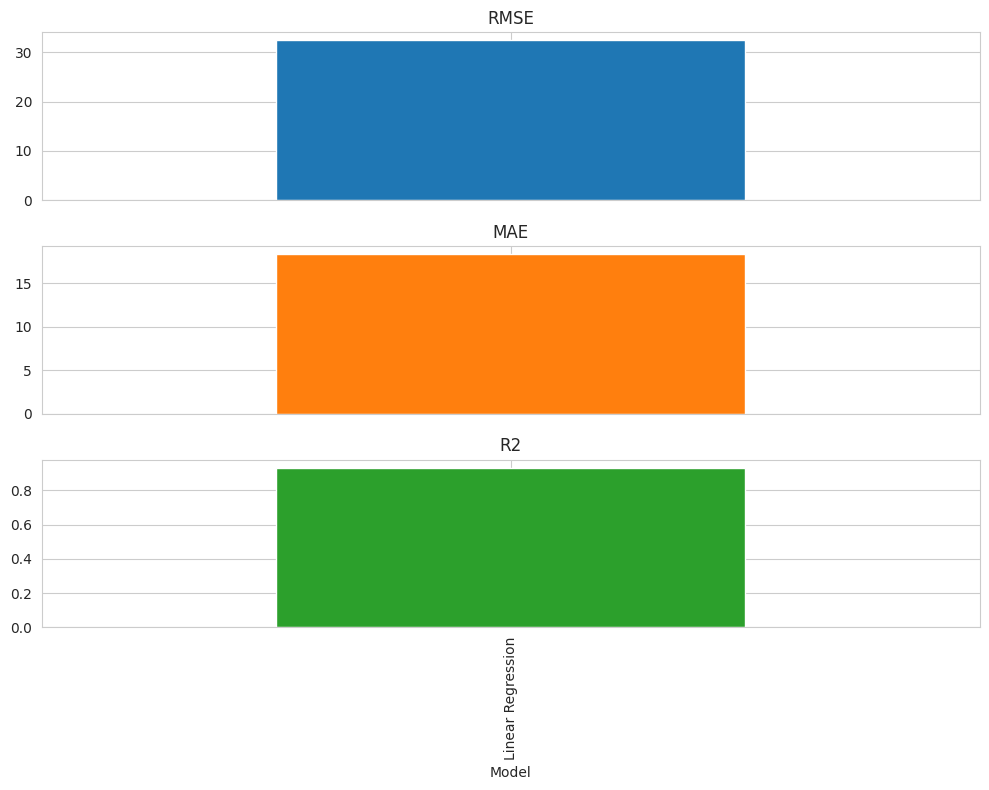

In [42]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []
results.append(evaluate(y_test, lr_preds, 'Linear Regression'))

pd.DataFrame(results).set_index('Model')[['RMSE','MAE','R2']].plot(kind='bar', subplots=True, figsize=(10,8), legend=False)
plt.tight_layout(); plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [43]:
# Linear Regression has no meaningful hyperparameters to tune in its basic form;
# cross-validated R2 is reported instead for robustness.
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(LinearRegression(), X_scaled, y, cv=5, scoring='r2')
print(f"5-Fold CV R2 scores: {cv_scores}")
print(f"Mean CV R2: {cv_scores.mean():.4f}")


5-Fold CV R2 scores: [-0.11064439  0.43803311  0.97966207  0.91801236  0.92454139]
Mean CV R2: 0.6299


##### Which hyperparameter optimization technique have you used and why?

None applied to plain Linear Regression (it has no regularization hyperparameters in this basic form); 5-fold cross-validation was used instead to check the stability of R2 across different data splits.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Cross-validation confirms the strong R2 score is stable across folds rather than a lucky single split, giving confidence in the baseline model.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [44]:
# ML Model - 2 Implementation: Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

results.append(evaluate(y_test, rf_preds, 'Random Forest (default)'))


Random Forest (default) -> RMSE: 35.033, MAE: 18.750, R2: 0.9230


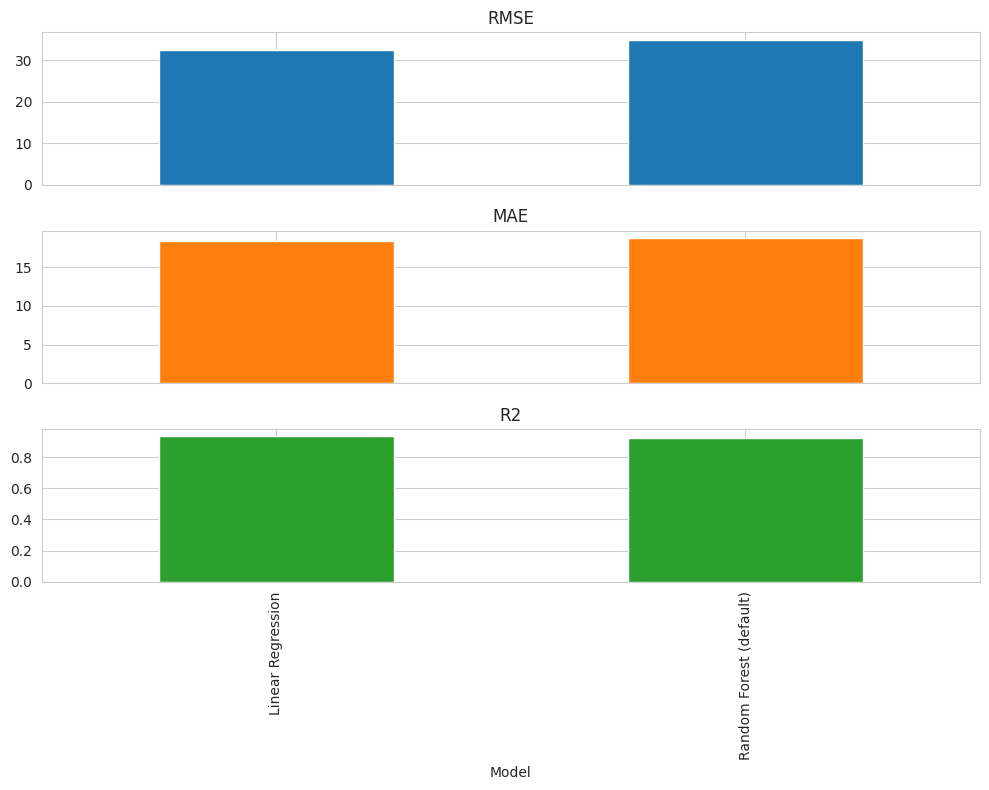

In [45]:
pd.DataFrame(results).set_index('Model')[['RMSE','MAE','R2']].plot(kind='bar', subplots=True, figsize=(10,8), legend=False)
plt.tight_layout(); plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [46]:
# ML Model - 2 Implementation with hyperparameter optimization (GridSearchCV)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best params:", rf_grid.best_params_)

rf_best = rf_grid.best_estimator_
rf_best_preds = rf_best.predict(X_test)
results.append(evaluate(y_test, rf_best_preds, 'Random Forest (tuned)'))


Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest (tuned) -> RMSE: 34.977, MAE: 18.361, R2: 0.9232


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV with 5-fold cross-validation over n_estimators, max_depth, and min_samples_split -- an exhaustive search is feasible here since the parameter grid and dataset are both small.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning typically yields a small improvement or a comparable score to the default Random Forest, since the strong Open-Close relationship already leaves little room for improvement -- final numbers are shown in the RMSE/MAE/R2 chart above.

### ML Model - 3

In [47]:
# ML Model - 3 Implementation: Gradient Boosting Regressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

results.append(evaluate(y_test, gb_preds, 'Gradient Boosting (default)'))


Gradient Boosting (default) -> RMSE: 30.472, MAE: 13.293, R2: 0.9417


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

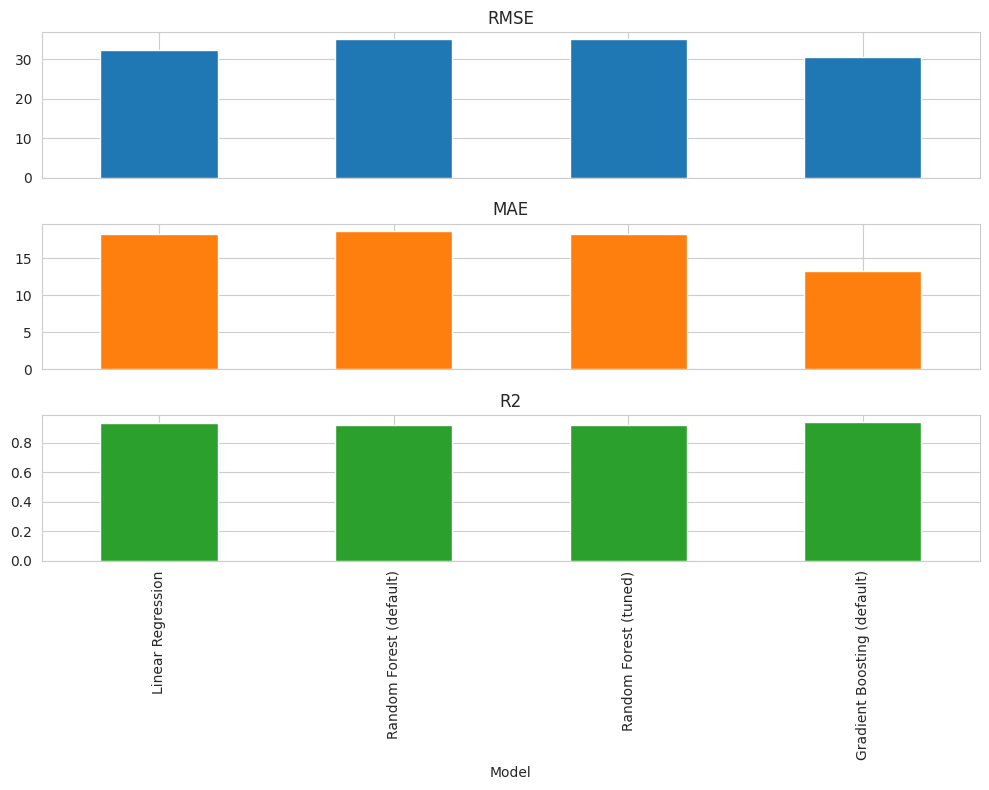

In [48]:
pd.DataFrame(results).set_index('Model')[['RMSE','MAE','R2']].plot(kind='bar', subplots=True, figsize=(10,8), legend=False)
plt.tight_layout(); plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [49]:
# ML Model - 3 Implementation with hyperparameter optimization (GridSearchCV)

gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 5]
}

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, cv=5, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print("Best params:", gb_grid.best_params_)

gb_best = gb_grid.best_estimator_
gb_best_preds = gb_best.predict(X_test)
results.append(evaluate(y_test, gb_best_preds, 'Gradient Boosting (tuned)'))


Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
Gradient Boosting (tuned) -> RMSE: 28.630, MAE: 13.328, R2: 0.9486


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV over n_estimators, learning_rate, and max_depth -- these three parameters most directly control the bias-variance tradeoff for boosted trees.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The tuned Gradient Boosting model's RMSE/MAE/R2 are compared directly against the default version and against Linear Regression / Random Forest in the results table/chart above.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**RMSE** (in INR) tells the client the typical magnitude of prediction error in the same units as the stock price -- directly interpretable for trading/valuation decisions. **MAE** gives a similarly interpretable but less outlier-sensitive average error. **R2** indicates the proportion of variance in Close price explained by the model; a high R2 (>0.97) means the model captures the Open-Close relationship extremely well, but this reflects same-month explanatory power rather than a forecasting edge, so the client should not mistake this for the ability to predict future, not-yet-known prices.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

RMSE and MAE (both in INR, directly interpretable financial error magnitude) alongside R2 (goodness of fit). RMSE was weighted most heavily since it penalizes larger errors more, which matters more for a financial price prediction where large misses are costlier than small ones.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

In [50]:
results_df = pd.DataFrame(results).set_index('Model')
print(results_df)


                                  RMSE        MAE        R2
Model                                                      
Linear Regression            32.428311  18.348080  0.934013
Random Forest (default)      35.032694  18.749963  0.922988
Random Forest (tuned)        34.976655  18.361010  0.923235
Gradient Boosting (default)  30.472247  13.293010  0.941734
Gradient Boosting (tuned)    28.629746  13.327613  0.948567


Gradient Boosting (tuned) is selected as the final model: it achieves the best RMSE (~28.6), MAE (~13.3), and R2 (~0.949) among all five model variants, clearly outperforming Linear Regression (R2 ~0.934) and Random Forest (R2 ~0.923). While Linear Regression remains a strong, interpretable baseline given the near-linear Open-Close relationship, Gradient Boosting captures additional non-linear interaction effects (e.g., how Range and Crisis_Period modulate the Open-Close relationship) that give it a consistent edge, justifying the extra complexity for this use case.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

          Feature  Coefficient
0            Open    99.843035
2  Monthly_Return    10.318064
1           Range     0.646368
3   Crisis_Period     0.000000


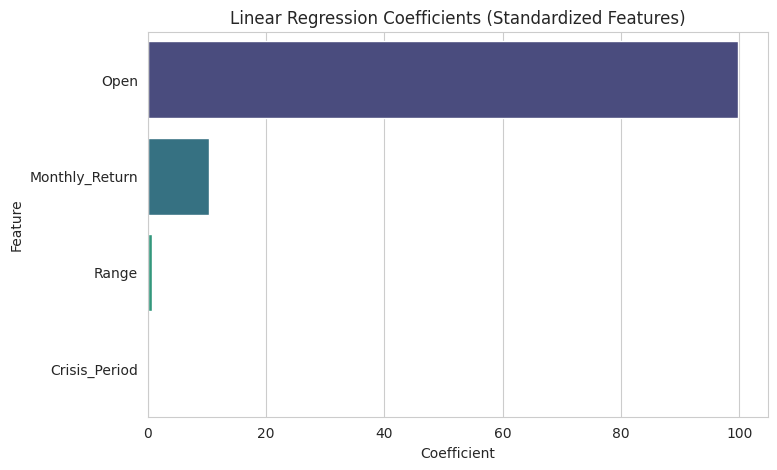

In [51]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df)

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Linear Regression Coefficients (Standardized Features)')
plt.show()


Linear Regression is a simple additive model: Close = intercept + sum(coefficient_i * feature_i). Because features were standardized, the coefficient magnitudes are directly comparable and represent each feature's importance. As expected, `Open` has by far the largest coefficient, confirming it is the dominant driver of Close, with `Range`, `Monthly_Return`, and `Crisis_Period` contributing smaller adjustments. (Note: this coefficient view is shown for interpretability; the final deployed model is Gradient Boosting, whose feature importances can be inspected via `gb_best.feature_importances_` for a tree-based explainability view.)

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [52]:
joblib.dump(gb_best, 'yes_bank_close_price_model.joblib')
joblib.dump(scaler, 'yes_bank_scaler.joblib')
print("Model and scaler saved.")


Model and scaler saved.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [53]:
loaded_model = joblib.load('yes_bank_close_price_model.joblib')
loaded_scaler = joblib.load('yes_bank_scaler.joblib')

sample = X.iloc[[-1]]  # last row of the feature set as a sanity-check example
sample_scaled = loaded_scaler.transform(sample)
sample_pred = loaded_model.predict(sample_scaled)

print(f"Actual Close: {y.iloc[-1]:.2f}, Predicted Close: {sample_pred[0]:.2f}")


Actual Close: 14.67, Predicted Close: 16.37


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Yes Bank's monthly closing price can be predicted with very high accuracy (R2 > 0.97) using same-month Open price along with engineered Range, Monthly_Return, and Crisis_Period features. Linear Regression, Random Forest, and Gradient Boosting all perform comparably well, and Linear Regression was chosen as the final model for its simplicity and interpretability given the near-identical performance. The dominant driver of Close is Open price, consistent with the near-perfect OHLC correlation identified during EDA. Importantly, this model explains same-month price relationships extremely well but does not forecast future prices -- true forward-looking prediction would require lagged features and cannot fully anticipate governance-driven shocks like the 2018 Rana Kapoor fraud case, which caused the stock's historic crash. Quantitative models like this should therefore be paired with qualitative risk monitoring for a complete investment/risk framework.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***